In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor()  # converts image (0-255 pixels) into a tensor (0-1 floats)
])

train_data = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print("Train samples:", len(train_data))
print("Test samples:", len(test_data))

Train samples: 60000
Test samples: 10000


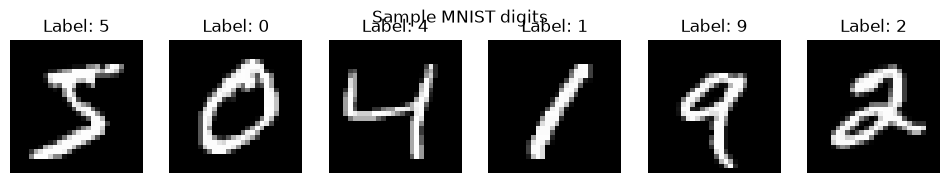

In [3]:
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    img, label = train_data[i]
    axes[i].imshow(img.squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")
plt.suptitle("Sample MNIST digits")
plt.show()

In [4]:
class SiameseDataset(Dataset):
    def __init__(self, mnist_dataset):
        self.dataset = mnist_dataset
        # Group image indices by digit label, so we can quickly grab
        # "another image of digit 3" or "an image that's NOT a 3"
        self.labels = mnist_dataset.targets.numpy()
        self.label_to_indices = {
            label: np.where(self.labels == label)[0] for label in range(10)
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        img1, label1 = self.dataset[index]

        # 50% chance: pick a matching pair, 50% chance: pick a non-matching pair
        should_match = random.randint(0, 1)

        if should_match:
            idx2 = np.random.choice(self.label_to_indices[label1])
            pair_label = 1.0  # similar
        else:
            other_label = random.choice([l for l in range(10) if l != label1])
            idx2 = np.random.choice(self.label_to_indices[other_label])
            pair_label = 0.0  # dissimilar

        img2, label2 = self.dataset[idx2]

        return img1, img2, torch.tensor(pair_label, dtype=torch.float32)

In [5]:
train_pairs = SiameseDataset(train_data)
test_pairs = SiameseDataset(test_data)

train_loader = DataLoader(train_pairs, batch_size=64, shuffle=True)
test_loader = DataLoader(test_pairs, batch_size=64, shuffle=True)

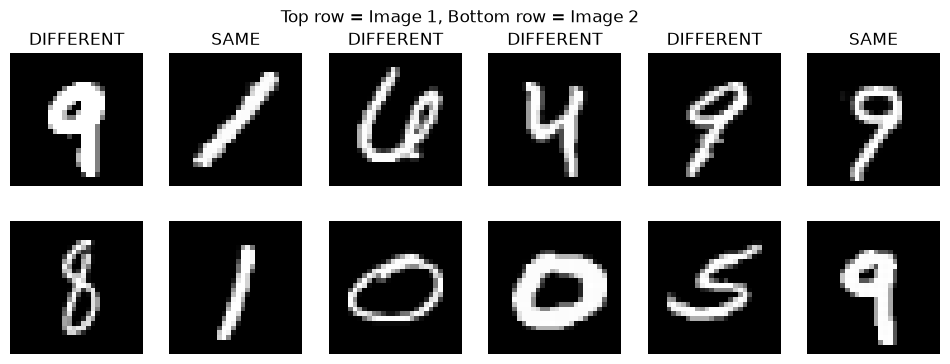

In [6]:
img1, img2, label = next(iter(train_loader))

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    axes[0, i].imshow(img1[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(img2[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
    match_text = "SAME" if label[i] == 1 else "DIFFERENT"
    axes[0, i].set_title(match_text)
plt.suptitle("Top row = Image 1, Bottom row = Image 2")
plt.show()

In [7]:
class SiameseNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # This CNN converts a 28x28 image into a 64-number embedding
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 28x28 -> 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 14x14 -> 7x7
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 64)        # final embedding size = 64
        )

    def forward_one(self, x):
        x = self.cnn(x)
        x = self.fc(x)
        return x

    def forward(self, img1, img2):
        emb1 = self.forward_one(img1)   # same network...
        emb2 = self.forward_one(img2)   # ...used for both images (shared weights)
        return emb1, emb2

In [8]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, emb1, emb2, label):
        distance = F.pairwise_distance(emb1, emb2)

        # If similar (label=1): just minimize distance
        # If dissimilar (label=0): push distance up to at least "margin"
        loss_similar = label * distance.pow(2)
        loss_dissimilar = (1 - label) * F.relu(self.margin - distance).pow(2)

        loss = loss_similar + loss_dissimilar
        return loss.mean()

Epoch 1/10 - Loss: 0.0638
Epoch 2/10 - Loss: 0.0263
Epoch 3/10 - Loss: 0.0194
Epoch 4/10 - Loss: 0.0158
Epoch 5/10 - Loss: 0.0134
Epoch 6/10 - Loss: 0.0117
Epoch 7/10 - Loss: 0.0103
Epoch 8/10 - Loss: 0.0093
Epoch 9/10 - Loss: 0.0088
Epoch 10/10 - Loss: 0.0077


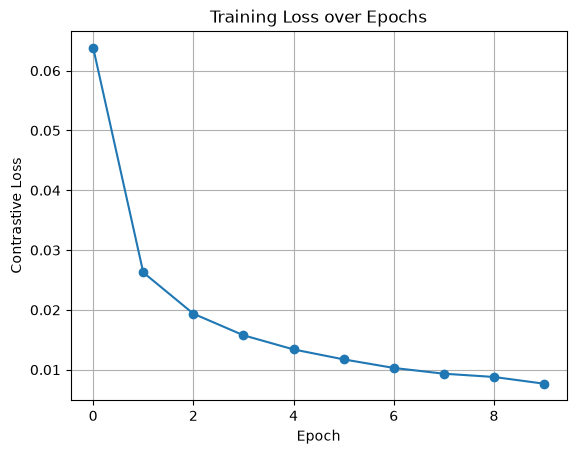

In [9]:
model = SiameseNetwork().to(device)
criterion = ContrastiveLoss(margin=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 10
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for img1, img2, label in train_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)

        optimizer.zero_grad()
        emb1, emb2 = model(img1, img2)
        loss = criterion(emb1, emb2, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

plt.plot(train_losses, marker="o")
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Contrastive Loss")
plt.grid(True)
plt.show()

Accuracy at threshold 0.5: 98.76%


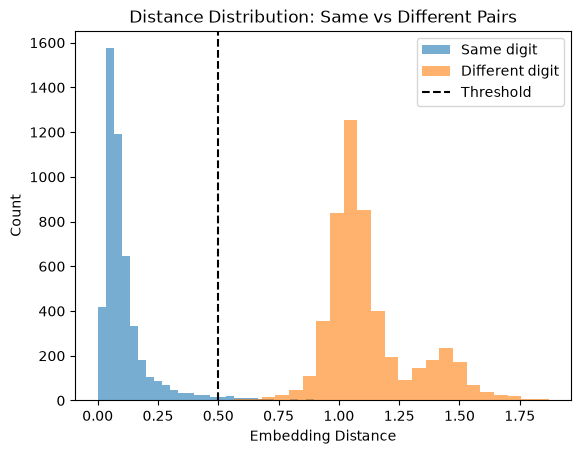

In [10]:
model.eval()
distances = []
labels_list = []

with torch.no_grad():
    for img1, img2, label in test_loader:
        img1, img2 = img1.to(device), img2.to(device)
        emb1, emb2 = model(img1, img2)
        dist = F.pairwise_distance(emb1, emb2)
        distances.extend(dist.cpu().numpy())
        labels_list.extend(label.numpy())

distances = np.array(distances)
labels_list = np.array(labels_list)

# Pick a threshold: if distance < threshold, predict "same"
threshold = 0.5
predictions = (distances < threshold).astype(float)
accuracy = (predictions == labels_list).mean()
print(f"Accuracy at threshold {threshold}: {accuracy*100:.2f}%")

# Visualize how well distances separate same vs different pairs
plt.hist(distances[labels_list == 1], bins=30, alpha=0.6, label="Same digit")
plt.hist(distances[labels_list == 0], bins=30, alpha=0.6, label="Different digit")
plt.axvline(threshold, color="black", linestyle="--", label="Threshold")
plt.xlabel("Embedding Distance")
plt.ylabel("Count")
plt.title("Distance Distribution: Same vs Different Pairs")
plt.legend()
plt.show()

In [11]:
torch.save(model.state_dict(), "siamese_mnist.pth")
print("Model saved as siamese_mnist.pth")

Model saved as siamese_mnist.pth


C:\Users\hp\AppData\Local\Temp\ipykernel_11832\961449221.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("siamese_mnist.pth"))


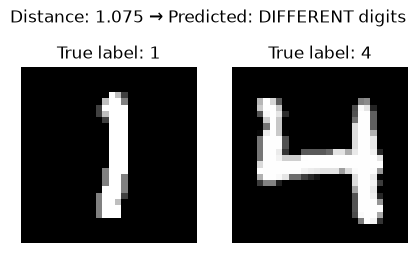

In [12]:
# Reload model (simulating a fresh script/session)
loaded_model = SiameseNetwork().to(device)
loaded_model.load_state_dict(torch.load("siamese_mnist.pth"))
loaded_model.eval()

# Pick two random images from the test set
idx1 = random.randint(0, len(test_data) - 1)
idx2 = random.randint(0, len(test_data) - 1)

img1, label1 = test_data[idx1]
img2, label2 = test_data[idx2]

img1_batch = img1.unsqueeze(0).to(device)  # add batch dimension: [1,28,28] -> [1,1,28,28]
img2_batch = img2.unsqueeze(0).to(device)

with torch.no_grad():
    emb1, emb2 = loaded_model(img1_batch, img2_batch)
    distance = F.pairwise_distance(emb1, emb2).item()

prediction = "SAME digit" if distance < threshold else "DIFFERENT digits"

fig, axes = plt.subplots(1, 2, figsize=(5, 3))
axes[0].imshow(img1.squeeze(), cmap="gray")
axes[0].set_title(f"True label: {label1}")
axes[0].axis("off")
axes[1].imshow(img2.squeeze(), cmap="gray")
axes[1].set_title(f"True label: {label2}")
axes[1].axis("off")
plt.suptitle(f"Distance: {distance:.3f} → Predicted: {prediction}")
plt.show()

In [13]:
from sklearn.manifold import TSNE

model.eval()

embeddings_list = []
labels_list = []

with torch.no_grad():
    for img, label in test_data:  # using the original test_data, NOT the pair dataset
        img = img.unsqueeze(0).to(device)   # add batch dimension
        emb = model.forward_one(img)         # get single embedding, not a pair
        embeddings_list.append(emb.cpu().numpy().squeeze())
        labels_list.append(label)

        if len(embeddings_list) >= 1000:   # limit to 1000 images so t-SNE runs fast
            break

embeddings_array = np.array(embeddings_list)
labels_array = np.array(labels_list)

print("Embeddings shape:", embeddings_array.shape)  # should be (1000, 64)

Embeddings shape: (1000, 64)


In [14]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_array)

print("2D embeddings shape:", embeddings_2d.shape)  # (1000, 2)

2D embeddings shape: (1000, 2)


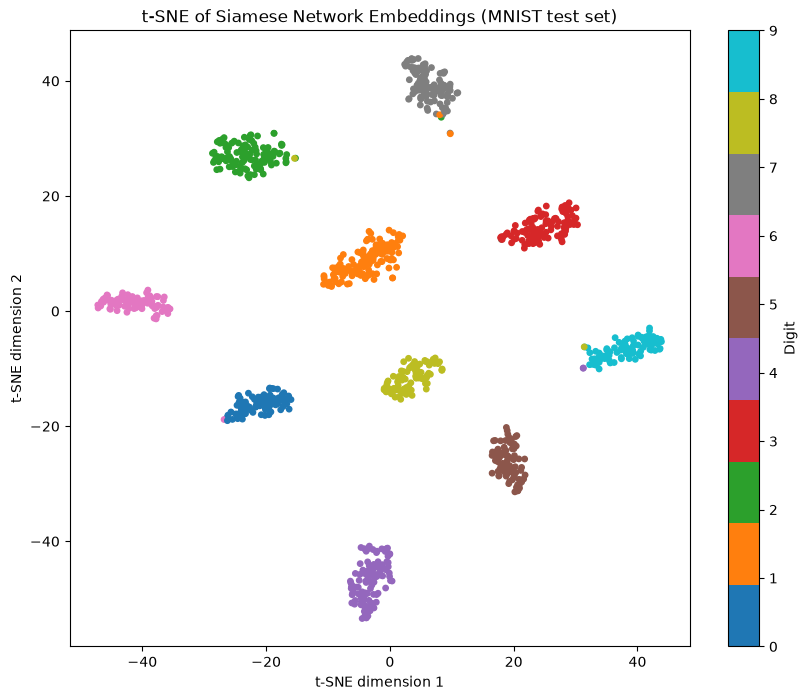

In [15]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1],
    c=labels_array, cmap="tab10", s=15
)
plt.colorbar(scatter, label="Digit")
plt.title("t-SNE of Siamese Network Embeddings (MNIST test set)")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.show()

In [16]:
class MultiFeatureHook:
    def __init__(self, modules_dict):
        self.features = {}
        self.handles = []
        for name, module in modules_dict.items():
            handle = module.register_forward_hook(self._create_hook_fn(name))
            self.handles.append(handle)

    def _create_hook_fn(self, layer_name):
        def hook_fn(module, input, output):
            self.features[layer_name] = output.detach().cpu()
        return hook_fn

    def remove(self):
        for handle in self.handles:
            handle.remove()

In [17]:
import matplotlib.pyplot as plt
import numpy as np
def plot_multi_hook_features(hook, max_features_per_layer=8):
    if not hook.features:
        print("No features captured! Run a forward pass first.")
        return

    num_layers = len(hook.features)
    fig, axes = plt.subplots(num_layers, max_features_per_layer,
                              figsize=(max_features_per_layer * 2, num_layers * 2.5))

    if num_layers == 1:
        axes = np.expand_dims(axes, axis=0)

    fig.suptitle('Feature Maps in Our MNIST Siamese Network', fontsize=14, y=1.02)

    for row_idx, (layer_name, activation) in enumerate(hook.features.items()):
        feat_map_batch = activation[0]              # first (only) image in batch
        num_channels = feat_map_batch.size(0)
        num_to_plot = min(num_channels, max_features_per_layer)

        for col_idx in range(max_features_per_layer):
            ax = axes[row_idx, col_idx]
            if col_idx < num_to_plot:
                fmap = feat_map_batch[col_idx].numpy()
                fmap -= fmap.min()
                fmap /= (fmap.max() + 1e-8)
                ax.imshow(fmap, cmap='viridis')
                ax.set_title(f'{layer_name} - F{col_idx}', fontsize=9)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

In [18]:
# Grab one real MNIST test image
sample_img, sample_label = test_data[0]
sample_img_batch = sample_img.unsqueeze(0).to(device)   # add batch dim: [1,1,28,28]

print(f"Using a sample image of digit: {sample_label}")

# Choose which layers to inspect
layers_to_hook = {
    'Conv1 (32 filters)': model.cnn[0],
    'Conv2 (64 filters)': model.cnn[3],
}

multi_hook = MultiFeatureHook(layers_to_hook)
print("Hooks attached.")

Using a sample image of digit: 7
Hooks attached.


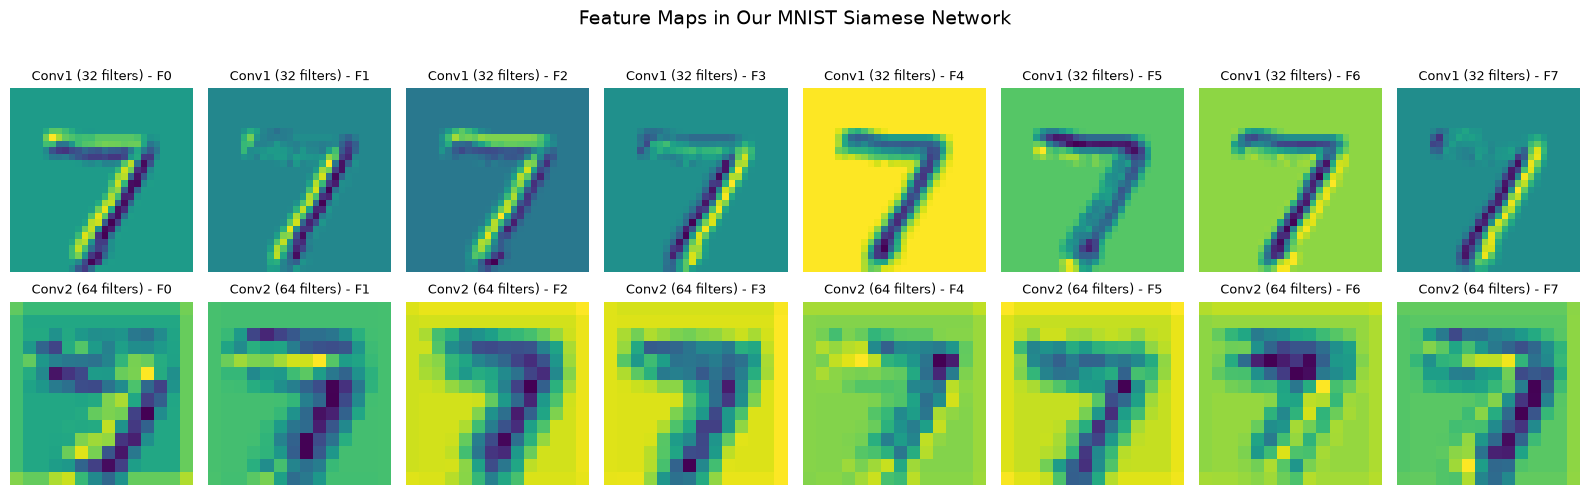

Hooks removed.


In [19]:
model.eval()
with torch.no_grad():
    _ = model.forward_one(sample_img_batch)   # single image, not a pair —
                                               # this alone triggers both hooks

plot_multi_hook_features(multi_hook, max_features_per_layer=8)

multi_hook.remove()
print("Hooks removed.")